# PersonaCore — Milestone 1 Results Showcase

PersonaCore is a conversational AI whose **memory and personalization live in the model
weights — no databases, no vector stores, no external files.** Updating the model's own
parameters *is* the personalization mechanism, which makes privacy a property of the
design rather than a policy. The entire stack — GPT-style transformer decoder, byte-level
BPE tokenizer, training loop, evaluation harness — is built from scratch in PyTorch and
runs fully on-device.

**What this notebook shows (and what it does not claim).** This is the **Milestone 1**
evidence artifact: the from-scratch foundation, trained on TinyStories and evaluated
rigorously. The weight-memory mechanism itself (LoRA adapters + EWC continual learning)
is **Milestone 2** — the seams are already in place (named linear projections, composable
loss assembly, open-dict checkpoints), but nothing below claims chat tuning or
personalization yet. What you see here is a 13.9M-parameter story-completion model and
the evidence that it was built correctly.

**Reproducibility.** All outputs below were produced on the pinned environment:
**Python 3.11, torch 2.7.1, CPU.** Every stochastic sampling cell is seeded; identical
seeds reproduce identical text **only on this pinned environment** (sampling draws depend
on the torch version and platform). The notebook re-runs end-to-end on CPU in the project
`.venv` — it loads the shipped inference checkpoint and the committed CSV logs, and never
trains anything.

In [1]:
import torch

from personacore.checkpoint import load_slim
from personacore.config import ModelConfig
from personacore.model import GPT
from personacore.tokenizer import from_json

# One shippable artifact shared by notebook, demo, and test (D-08). load_slim enforces
# weights_only=True: tensors + primitive containers only, zero code execution on load.
ckpt = load_slim("checkpoints/model_slim.pt")

model = GPT(ModelConfig(**ckpt["model_config"]))
model.load_state_dict(ckpt["model"])
model.eval()
tok = from_json("artifacts/tokenizer.json")  # frozen tokenizer — data-only load

# Exact parameter count, deduplicated by storage pointer: wte/lm_head are TIED, so the
# shared tensor must be counted exactly once.
seen, n_params = set(), 0
for p in model.parameters():
    if p.data_ptr() not in seen:
        seen.add(p.data_ptr())
        n_params += p.numel()

print(f"parameters : {n_params:,}")
print(f"git SHA    : {ckpt['git_sha']}")
print(f"step       : {ckpt['step']}")
print(f"val_loss at export : {ckpt['val_loss']:.4f}")

parameters : 13,891,584
git SHA    : 3a46815da96f06d3c6196bb0949a1479884b3bce
step       : 49000
val_loss at export : 0.7378


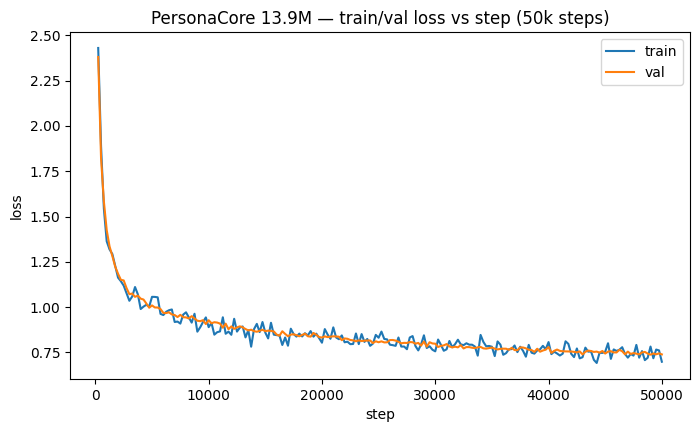

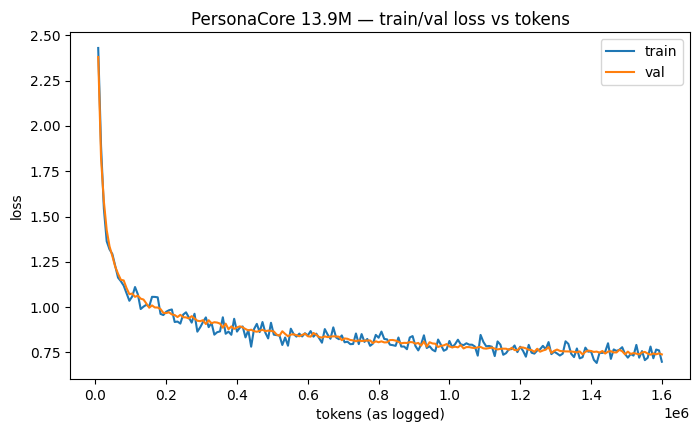

In [2]:
import csv

import matplotlib.pyplot as plt

# The COMMITTED copy of the 50k-step training log (the raw training-log directory is
# gitignored; this copy keeps the cell re-runnable from a fresh clone).
with open("results/run.csv") as f:
    rows = list(csv.DictReader(f))

steps = [int(r["step"]) for r in rows]
tokens = [int(r["tokens"]) for r in rows]
train_loss = [float(r["train_loss"]) for r in rows]
val_loss = [float(r["val_loss"]) for r in rows]

plt.figure(figsize=(8, 4.5), dpi=100)
plt.plot(steps, train_loss, color="C0", label="train")
plt.plot(steps, val_loss, color="C1", label="val")
plt.xlabel("step")
plt.ylabel("loss")
plt.title("PersonaCore 13.9M — train/val loss vs step (50k steps)")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4.5), dpi=100)
plt.plot(tokens, train_loss, color="C0", label="train")
plt.plot(tokens, val_loss, color="C1", label="val")
plt.xlabel("tokens (as logged)")
plt.ylabel("loss")
plt.title("PersonaCore 13.9M — train/val loss vs tokens")
plt.legend()
plt.show()

## Headline evaluation (re-cited, never recomputed)

Deterministic full-validation perplexity of the 50k-step model:

**PPL 2.1066 over 12,636,922 scored target tokens**

produced by `scripts/evaluate.py` (EVAL-01) as a deterministic non-overlapping-window
sweep over the entire validation split. The number is committed in `results/results.md`
and re-cited here **with its token denominator**; this notebook never recomputes it —
the rigor lives in the audited script, not in an ad-hoc notebook cell.

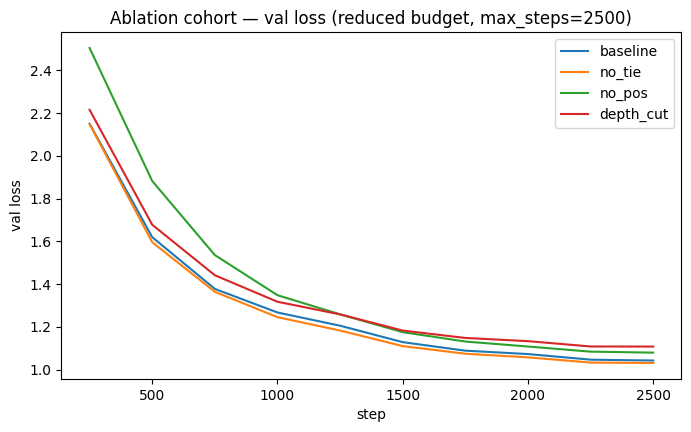

In [3]:
import csv

import matplotlib.pyplot as plt

# Fixed series order + colors (08-UI-SPEC plot contract): matplotlib default cycle only.
ABLATIONS = [
    ("baseline", "C0"),
    ("no_tie", "C1"),
    ("no_pos", "C2"),
    ("depth_cut", "C3"),
]

plt.figure(figsize=(8, 4.5), dpi=100)
for name, color in ABLATIONS:
    with open(f"results/abl_{name}.csv") as f:
        abl_rows = list(csv.DictReader(f))
    plt.plot(
        [int(r["step"]) for r in abl_rows],
        [float(r["val_loss"]) for r in abl_rows],
        color=color,
        label=name,
    )
plt.xlabel("step")
plt.ylabel("val loss")
plt.title("Ablation cohort — val loss (reduced budget, max_steps=2500)")
plt.legend()
plt.show()

## Ablation cohort (EVAL-03)

From `results/results.md`, reproduced verbatim — the caveat is part of the result:

> **Reduced-budget, self-consistent cohort (D-06).** All four runs below train through
> the UNTOUCHED `train()` harness at IDENTICAL seed (1337), data, LR, warmup, and
> budget (`max_steps=2500`, calibrated per D-07) — only the ablated knob
> differs. The numbers are comparable to EACH OTHER, NOT to the headline 50k `best.pt`.
>
> The headline production figure is reported SEPARATELY (EVAL-01, `scripts/evaluate.py`):
> deterministic full-val perplexity **2.1066** over **12,636,922** scored target tokens
> on the 50k-step `best.pt` — a different (larger) budget, listed here only for context.

| Variant | Param count | Held-out PPL (reduced budget) | Best val-loss | What this shows |
| --- | --- | --- | --- | --- |
| baseline | 13,891,584 | 2.8212 (over 12,636,922 tokens) | 1.0426 | The fair reference — full 6-layer tied + positional arch at the reduced budget. |
| no_tie | 17,037,312 | 2.7870 (over 12,636,922 tokens) | 1.0312 | Whether sharing the input/output embedding helps (or hurts) at this scale. |
| no_pos | 13,793,280 | 2.9221 (over 12,636,922 tokens) | 1.0796 | Whether the learned positional embedding is load-bearing for coherence. |
| depth_cut | 8,568,192 | 3.0074 (over 12,636,922 tokens) | 1.1078 | The depth-vs-params tradeoff: half the layers (~38% fewer params), equal budget. |

## Sampling settings tour

One fixed prompt, four decoding settings, all through the from-scratch sampling toolkit
(greedy argmax, temperature scaling, top-k, nucleus/top-p). The outputs below are
**REPRESENTATIVE, not cherry-picked**: the prompt is fixed, every stochastic call passes
a fresh `torch.Generator().manual_seed(1337)`, and the greedy run is deterministic by
construction. The point is to show *how* each sampling choice changes the text — not to
showcase a lucky draw.

In [4]:
import torch

from personacore.generation import generate_text_str

PROMPT = "Once upon a time, there was a little dog named Max."
SETTINGS = [
    ("greedy (deterministic)", {"greedy": True}),
    ("temperature=0.8", {"temperature": 0.8}),
    ("temperature=0.8, top_k=50", {"temperature": 0.8, "top_k": 50}),
    ("temperature=0.8, top_p=0.95", {"temperature": 0.8, "top_p": 0.95}),
]

for label, gen_kw in SETTINGS:
    if not gen_kw.get("greedy"):
        # Fresh seeded generator per call (reproducibility): every setting samples from
        # the SAME random stream, so differences come from the setting, not the draw.
        gen_kw = {**gen_kw, "generator": torch.Generator().manual_seed(1337)}
    continuation = generate_text_str(model, tok, PROMPT, max_new_tokens=120, **gen_kw)
    print(f"=== {label} ===")
    print(PROMPT + continuation)
    print()

=== greedy (deterministic) ===
Once upon a time, there was a little dog named Max. Max loved to play outside in the sun. One day, Max saw a big, red ball in the yard. He wanted to play with it, but he knew it was not his.
Max went to his friend, a cat named Lily. Max said, "Lily, I found a big, red ball. Let's play with it!" Lily was happy and



=== temperature=0.8 ===
Once upon a time, there was a little dog named Max. Max was a very quiet dog. He liked to play with his friends, the birds and the squirrels.
One day, Max saw a big hole in the ground. He was curious and went to see what was inside. Max wanted to see what was in the hole. He shouted, "Hello, ho



=== temperature=0.8, top_k=50 ===
Once upon a time, there was a little dog named Max. Max was a very quiet dog. He liked to play with his friends, the birds and the squirrels.
One day, Max saw a big hole in the ground. He was curious and went to see what was inside. Max wanted to see what was in the hole. He shouted, "Hello, ho



=== temperature=0.8, top_p=0.95 ===
Once upon a time, there was a little dog named Max. Max was a very reliable dog. He always did what his owner, Tom, told him to do. Max lived in a small house with a big fireplace. One day, Tom saw a big box in the yard. He thought it was a new home.
Max went to his friend, a cat named L

